27
1.20522


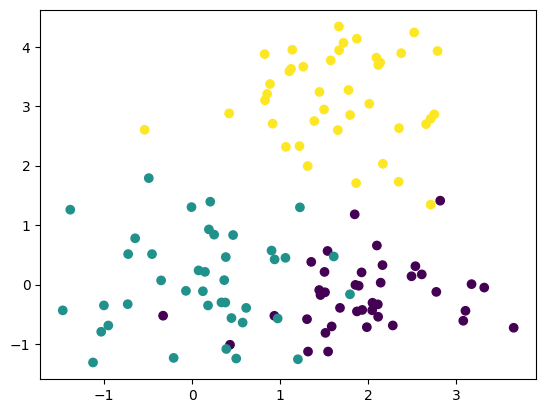

1.2052226066589355
1.3083451986312866 1.6673327684402466


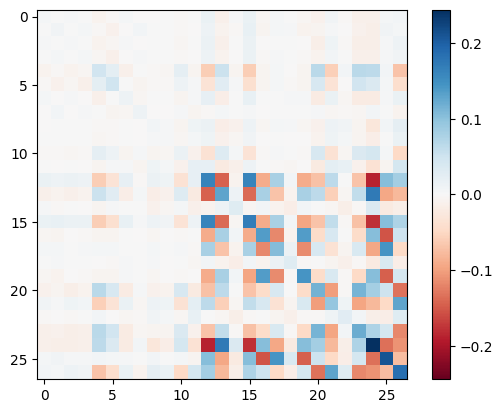

0.1576
0.15756478905677795
3.652510643005371 1.1959091424942017
0.1427874118089676
0.24721288681030273


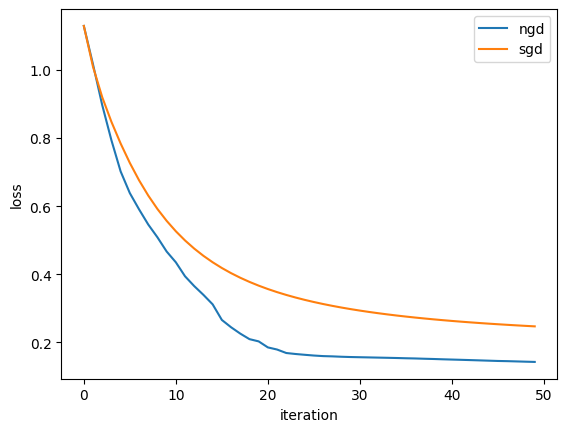

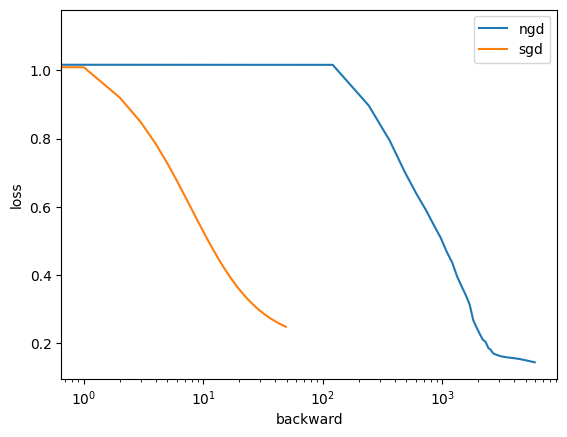

'each NGD step costs 121 backwards, this graph shows us the reality,\nSGD is better, we need to improve NGD'

In [3]:
# 02_mlp — exact Fisher matrix on a toy MLP
# Here: true vs empirical Fisher, natural gradient descent, cost comparison

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(1)
A = torch.randn(40, 2) * 0.7 + torch.tensor([2, 0])   # (2,0)
B = torch.randn(40, 2) * 0.7                          # (0,0)
C = torch.randn(40, 2) * 0.7 + torch.tensor([1.5, 3])  # (1.5,3)
X = torch.cat([A, B, C], dim=0)   # the entries

Z = torch.zeros(40, dtype=torch.long)
O = torch.ones(40, dtype=torch.long)
T = torch.full((40,), 2)
Y = torch.cat([Z, O, T], dim=0)   # targets, label per entry

model = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 3))
loss_fn = nn.CrossEntropyLoss()

D = sum(p.numel() for p in model.parameters())
print(D)
print(f"{loss_fn(model(X), Y).item():.5f}")
"""  log(3) = 1.09861 """

plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()


def fisher_mat(labels):
    """F = average over the dataset of outer(score, score), one per point.
    labels sampled from the model -> true Fisher; labels = Y -> empirical Fisher."""
    M = torch.zeros(D, D)
    for i in range(len(X)):
        model.zero_grad()   # clears the gradients from the previous step
        # X[i:i+1] keeps a (1, 2) matrix for the model, avoiding (2,)
        loss_fn(model(X[i:i+1]), labels[i:i+1]).backward()
        g = torch.cat([p.grad.flatten() for p in model.parameters()])
        M += torch.outer(g, g)   # g_i * g_j, Monte-Carlo while "sum + mean"
    return M / len(X)


def sample_labels():
    return torch.multinomial(torch.softmax(model(X), dim=1), 1).squeeze(1)


""" F is the average of 120 matrices, one per data point.
For each point, we obtain a vector of 27 numbers (parameters) called the score.
We make a 27x27 matrix by multiplying each component by each other.
Then, we average the 120 matrices obtained. """

torch.manual_seed(42)
F = fisher_mat(sample_labels())
F_emp = fisher_mat(Y)

print(loss_fn(model(X), Y).item())
print(F.norm().item(), F_emp.norm().item())
# 1.2052  ->  1.3083 / 1.6673   not trained

plt.imshow(F, cmap='RdBu', vmin=-F.abs().max(), vmax=F.abs().max())
plt.colorbar()
plt.show()

# train the model, then rebuild both matrices on the trained model
opt = torch.optim.SGD(model.parameters(), lr=0.5)
for i in range(2000):
    opt.zero_grad()
    loss_fn(model(X), Y).backward()
    opt.step()
print(f"{loss_fn(model(X), Y).item():.4f}")

torch.manual_seed(42)
F = fisher_mat(sample_labels())
F_emp = fisher_mat(Y)

print(loss_fn(model(X), Y).item())
print(F.norm().item(), F_emp.norm().item())
# 0.1494  ->  3.2447 / 1.9032   trained

""" F must be built with labels derived from the distribution of the model,
not with the real answers. We observe that as he learns, the model becomes
confident and F records this change in geometry, whereas F_emp misses it."""

# natural gradient descent
torch.manual_seed(7)
model = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 3))
eta = 0.1
lam = 1e-3

losses_ngd = []
for it in range(50):
    losses_ngd.append(loss_fn(model(X), Y).item())

    # 1. direction, with the real labels
    model.zero_grad()
    loss_fn(model(X), Y).backward()
    grad = torch.cat([p.grad.flatten() for p in model.parameters()])

    # 2. metric, with labels sampled from the model
    Fmat = fisher_mat(sample_labels())

    # 3. step, lam * I to make F invertible (damping)
    d = -eta * torch.linalg.solve(Fmat + lam * torch.eye(D), grad)

    # 4. uploading, d is a flat vector, parameters are four tensors
    with torch.no_grad():
        k = 0
        for p in model.parameters():
            n = p.numel()
            p += d[k:k+n].view_as(p)
            k += n

print(losses_ngd[-1])

# same starting point, plain SGD
torch.manual_seed(7)
model = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 3))
opt = torch.optim.SGD(model.parameters(), lr=0.5)

losses_sgd = []
for i in range(50):
    losses_sgd.append(loss_fn(model(X), Y).item())
    opt.zero_grad()
    loss_fn(model(X), Y).backward()
    opt.step()

print(losses_sgd[-1])

plt.plot(losses_ngd, label="ngd")
plt.plot(losses_sgd, label="sgd")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.legend()
plt.show()

""" I think the graph tells us what we want to know !... not. really"""

cost_ngd = 1 + len(X)   # one backward for the direction, 120 for the metric

plt.plot(np.arange(50) * cost_ngd, losses_ngd, label="ngd")
plt.plot(np.arange(50), losses_sgd, label="sgd")
plt.xscale("log")
plt.xlabel("backward"); plt.ylabel("loss"); plt.legend()
plt.show()

"""each NGD step costs 121 backwards, this graph shows us the reality,
SGD is better, we need to improve NGD"""